# Swin-Unet - Palm Leaf Manuscript Text-Line Segmentation
### LeafOCR-Line · Malayalam Script · Variable-Size Image Inference

---

**Architecture:** Swin-Unet - pure Transformer U-shaped Encoder-Decoder  
- Encoder: hierarchical Swin Transformer + Patch Merging (W-MSA / SW-MSA)  
- Bottleneck: 2x Swin Transformer blocks  
- Decoder: Swin Transformer + Patch Expanding (up-sampling)  
- Skip connections: concat shallow + deep features  

**Dataset:** LeafOCR-Line - 1,710 Malayalam palm leaf images, 3 deterioration levels  
**Task:** Binary segmentation - extract text regions from degraded palm leaf images  
**Metrics:** Dice Similarity Coefficient (DSC) + Hausdorff Distance (HD)  
**Variable-size:** Images are inferred at full original resolution (no forced resize at test time)



## Cell 1 - Mount Drive, GPU Check & Install Dependencies

In [1]:
# ─────────────────────────────────────────────────────────────
# Mount Drive → GPU check → install all dependencies
# ─────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import subprocess, sys
from pathlib import Path

# ── Drive directory layout ────────────────────────────────────
DRIVE_ROOT   = Path('/content/drive/MyDrive/DenoisingSegmentation')
REPO_DIR     = DRIVE_ROOT / 'Swin-Unet'          # cloned here (persistent)
OUTPUTS_DIR  = DRIVE_ROOT / 'Outputs'

for d in [REPO_DIR, OUTPUTS_DIR/'checkpoints',
          OUTPUTS_DIR/'logs', OUTPUTS_DIR/'predictions']:
    d.mkdir(parents=True, exist_ok=True)

print(f'   Drive mounted.')
print(f'   Repo    → {REPO_DIR}')
print(f'   Outputs → {OUTPUTS_DIR}')

# GPU check (hard stop on CPU)
import torch
# print(f'\nPyTorch : {torch.__version__}')
# if not torch.cuda.is_available():
#     raise SystemExit(' No GPU - Runtime > Change runtime type > T4 GPU')
# print(f'GPU     : {torch.cuda.get_device_name(0)}  ')

# Helper
def run(cmd, label=''):
    print(f'\n>>> {label or cmd[:70]}')
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print('STDERR:', r.stderr[-800:])
    else:
        print(r.stdout.strip()[-200:] or 'OK')
    return r.returncode

# Clone Swin-Unet repo to Drive
marker = REPO_DIR / 'networks' / 'vision_transformer.py'
if marker.exists():
    print(f'\n Swin-Unet repo already on Drive - skipping clone.')
else:
    print(f'\nCloning Swin-Unet → {REPO_DIR}')
    rc = run(f'git clone https://github.com/HuCaoFighting/Swin-Unet.git "{REPO_DIR}"',
             'git clone Swin-Unet')
    if rc != 0:
        raise RuntimeError('Clone failed.')

# Add repo to Python path
import sys
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

# Install dependencies
run('pip install -q timm einops opencv-python-headless albumentations '
    'scikit-image scipy matplotlib tqdm tensorboard',
    'Install libraries')

# Verify
print('\nVerification')
import timm, einops, albumentations as A
print(f'  timm           : {timm.__version__}  ')
print(f'  einops         : {einops.__version__}  ')
print(f'  albumentations : {A.__version__}  ')
print('\n Setup complete. Proceed to Cell 2.')

Mounted at /content/drive
   Drive mounted.
   Repo    → /content/drive/MyDrive/DenoisingSegmentation/Swin-Unet
   Outputs → /content/drive/MyDrive/DenoisingSegmentation/Outputs

 Swin-Unet repo already on Drive - skipping clone.

>>> Install libraries
OK

Verification
  timm           : 1.0.26  
  einops         : 0.8.2  
  albumentations : 2.0.8  

 Setup complete. Proceed to Cell 2.


## Cell 2 - Global Configuration

In [2]:
# ─────────────────────────────────────────────────────────────
# Configuration - all hyper-parameters in one place
# ─────────────────────────────────────────────────────────────

import torch
from pathlib import Path

class CFG:
    # Paths
    _ROOT       = Path('/content/drive/MyDrive/DenoisingSegmentation')
    REPO_DIR    = _ROOT / 'Swin-Unet'
    DATA_ROOT   = _ROOT / 'Dataset' / 'LeafOCR-Line'
    IMAGE_TRAIN = DATA_ROOT / 'Image' / 'image-train'
    IMAGE_VAL   = DATA_ROOT / 'Image' / 'image-val'
    IMAGE_TEST  = DATA_ROOT / 'Image' / 'image-test'
    MASK_TRAIN  = DATA_ROOT / 'Mask'  / 'mask-train'
    MASK_VAL    = DATA_ROOT / 'Mask'  / 'mask-val'
    MASK_TEST   = DATA_ROOT / 'Mask'  / 'mask-test'
    CKPT_DIR    = _ROOT / 'Outputs' / 'checkpoints'
    LOG_DIR     = _ROOT / 'Outputs' / 'logs'
    PRED_DIR    = _ROOT / 'Outputs' / 'predictions'

    # Device
    # DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DEVICE      = 'cpu'   # hardcoded - no GPU available
    SEED        = 42

    # Swin-Unet architecture
    IMG_SIZE        = 224
    PATCH_SIZE      = 4
    IN_CHANNELS     = 3
    NUM_CLASSES     = 2
    EMBED_DIM       = 96
    DEPTHS          = [2, 2, 2, 2]
    DEPTHS_DECODER  = [1, 2, 2, 2]
    NUM_HEADS       = [3, 6, 12, 24]
    WINDOW_SIZE     = 7
    MLP_RATIO       = 4.0
    DROP_RATE       = 0.0
    DROP_PATH_RATE  = 0.1
    APE             = False
    PATCH_NORM      = True
    USE_CHECKPOINT  = False
    FINAL_UPSAMPLE  = 'expand_first'

    # Training
    #    Swin-Unet on CPU: ~200 batches × ~15s/batch = ~50 min/epoch
    #    With 1198 train images, EPOCHS=10 takes ~8 hrs.
    #    Recommended: run 5-10 epochs, save checkpoint, resume next session.
    EPOCHS          = 2           # was 1 (too few) → 10 is practical for CPU

    BATCH_SIZE      = 2            # was 6 → smaller batch = faster per step on CPU
    BASE_LR         = 0.01
    MOMENTUM        = 0.9
    WEIGHT_DECAY    = 1e-4
    WARMUP_EPOCHS   = 2            # was 5 > EPOCHS → now 20% of 10
    MIN_LR          = 1e-6
    GRAD_CLIP       = 5.0

    # FIX: AMP=False - GradScaler/autocast are CUDA-only, crash silently on CPU
    AMP             = False        # was True → must be False on CPU

    # Loss
    DICE_WEIGHT     = 0.5
    CE_WEIGHT       = 0.5

    # Evaluation
    EVAL_EVERY      = 2            # was 5 > EPOCHS=10 → evaluate every 2 epochs
    SAVE_EVERY      = 5

    # DataLoader
    NUM_WORKERS     = 0            # was 2 → 0 avoids multiprocessing issues on CPU
    PIN_MEMORY      = False        # was True → pin_memory only helps with GPU


import random, numpy as np
def set_seed(s=CFG.SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    # No torch.cuda.manual_seed_all - not available/needed on CPU
set_seed()

print(f'Device     : {CFG.DEVICE}')
print(f'AMP        : {CFG.AMP}   (disabled - CPU only)')
print(f'Epochs     : {CFG.EPOCHS}  (warmup={CFG.WARMUP_EPOCHS})')
print(f'Batch size : {CFG.BATCH_SIZE}')
print(f'Workers    : {CFG.NUM_WORKERS}')
print()
print('   CPU Training time estimate:')
print('   ~15s per batch × ~600 batches/epoch × 2 epochs ≈ 5 hrs total')
print('   Tip: run 2 epochs at a time, save checkpoint, resume next session.')

# Verify dataset paths
IMG_EXTS = {'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}
print('\n Dataset Verification')
splits = [
    ('Train images', CFG.IMAGE_TRAIN), ('Train masks', CFG.MASK_TRAIN),
    ('Val   images', CFG.IMAGE_VAL),   ('Val   masks', CFG.MASK_VAL),
    ('Test  images', CFG.IMAGE_TEST),  ('Test  masks', CFG.MASK_TEST),
]
for name, path in splits:
    n = sum(1 for p in path.iterdir() if p.suffix in IMG_EXTS) if path.exists() else -1
    ok = 'Yes' if n > 0 else 'No'
    print(f'  {ok}  {name:<20} {n:>5} files')


Device     : cpu
AMP        : False   (disabled - CPU only)
Epochs     : 2  (warmup=2)
Batch size : 2
Workers    : 0

   CPU Training time estimate:
   ~15s per batch × ~600 batches/epoch × 2 epochs ≈ 5 hrs total
   Tip: run 2 epochs at a time, save checkpoint, resume next session.

 Dataset Verification
  Yes  Train images          1198 files
  Yes  Train masks           1198 files
  Yes  Val   images           255 files
  Yes  Val   masks            255 files
  Yes  Test  images           257 files
  Yes  Test  masks            257 files


## Cell 3 - Dataset & DataLoader (Variable-Size Aware)

In [4]:
# ─────────────────────────────────────────────────────────────
# Cell 3: PalmLeafDataset + albumentations transforms
# ─────────────────────────────────────────────────────────────
import cv2, numpy as np, torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

_ALB = tuple(int(x) for x in A.__version__.split('.')[:2])
_MEAN, _STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)


def _read_mask(path: str) -> np.ndarray:
    """
    Correct mask reading for COLOUR ground-truth masks.
    Any non-black pixel = text (1), pure black = background (0).
    Old code used IMREAD_GRAYSCALE + threshold 127 which caused
    dark colours like dark-red (139,0,0) → grayscale≈18 → misread as background.
    """
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f'Cannot read mask: {path}')
    return (bgr.max(axis=2) > 0).astype(np.uint8)


def _crop(h, w):
    if _ALB >= (1, 4):
        return A.RandomResizedCrop(size=(h,w), scale=(0.7,1.0), ratio=(0.5,2.0))
    return A.RandomResizedCrop(height=h, width=w, scale=(0.7,1.0), ratio=(0.5,2.0))

def _noise():
    try:
        return A.GaussNoise(std_range=(0.01,0.07), p=0.35) if _ALB>=(1,4) \
               else A.GaussNoise(var_limit=(5,25), p=0.35)
    except: return A.GaussNoise(p=0.35)

def _dropout():
    try:
        return A.CoarseDropout(num_holes_range=(1,4),
                               hole_height_range=(8,16),
                               hole_width_range=(16,32), fill=200, p=0.2) \
               if _ALB>=(1,4) \
               else A.CoarseDropout(max_holes=4, max_height=16,
                                    max_width=32, fill_value=200, p=0.2)
    except: return A.CoarseDropout(p=0.2)


def get_train_transforms(sz=CFG.IMG_SIZE):
    return A.Compose([
        _crop(sz, sz),
        # Removed HorizontalFlip - mirrored script text hurts convergence
        A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.1,
                           rotate_limit=3, border_mode=cv2.BORDER_REFLECT, p=0.5),
        A.ElasticTransform(alpha=25, sigma=4, p=0.25),
        A.OneOf([
            A.RandomBrightnessContrast(0.3, 0.3),
            A.HueSaturationValue(10, 20, 20),
            A.CLAHE(clip_limit=4.0),
        ], p=0.6),
        _noise(),
        A.Blur(blur_limit=3, p=0.15),
        A.RandomToneCurve(scale=0.2, p=0.2),
        _dropout(),
        A.Normalize(mean=_MEAN, std=_STD),
        ToTensorV2(),
    ])

def get_val_transforms(sz=CFG.IMG_SIZE):
    return A.Compose([
        A.Resize(sz, sz),
        A.Normalize(mean=_MEAN, std=_STD),
        ToTensorV2(),
    ])


class PalmLeafDataset(Dataset):
    IMG_EXTS = {'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}

    def __init__(self, image_dir, mask_dir, transforms=None, mode='train'):
        self.transforms = transforms
        self.mode = mode
        mask_lut = {p.stem: p for p in Path(mask_dir).iterdir()
                    if p.suffix.lower() in {'.png','.jpg','.jpeg'}}
        self.pairs, skipped = [], []
        for img in sorted(Path(image_dir).iterdir()):
            if img.suffix not in self.IMG_EXTS: continue
            if img.stem in mask_lut: self.pairs.append((img, mask_lut[img.stem]))
            else: skipped.append(img.stem)
        if skipped:
            print(f'  [{mode}] ⚠ {len(skipped)} images without mask - skipped.')
        if not self.pairs:
            raise FileNotFoundError(f'No pairs in {image_dir}')
        print(f'  [{mode}]  {len(self.pairs)} paired samples.')
        self._verify_masks(list(mask_lut.values()))

    def _verify_masks(self, mask_paths, n_check=5):
        print(f'  Verifying mask labels ({n_check} samples)...')
        for mp in mask_paths[:n_check]:
            m = _read_mask(str(mp))
            pct = m.mean() * 100
            status = 'Yes' if pct > 0.5 else 'No ALL BACKGROUND - check mask files!'
            print(f'    {status}  {mp.name}: text={pct:.1f}%')

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_p, msk_p = self.pairs[idx]
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        msk = _read_mask(str(msk_p))
        orig_h, orig_w = img.shape[:2]
        if self.transforms:
            out = self.transforms(image=img, mask=msk)
            img, msk = out['image'], out['mask']
        return {'image': img, 'mask': msk.long(),
                'img_path': str(img_p), 'orig_size': (orig_h, orig_w)}


# Build loaders
train_ds = PalmLeafDataset(CFG.IMAGE_TRAIN, CFG.MASK_TRAIN,
                           get_train_transforms(), mode='train')
val_ds   = PalmLeafDataset(CFG.IMAGE_VAL,   CFG.MASK_VAL,
                           get_val_transforms(),   mode='val')
test_ds  = PalmLeafDataset(CFG.IMAGE_TEST,  CFG.MASK_TEST,
                           get_val_transforms(),   mode='test')

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS,
                          pin_memory=CFG.PIN_MEMORY,   # False on CPU
                          drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS,
                          pin_memory=CFG.PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS,
                          pin_memory=CFG.PIN_MEMORY)

print(f'\n  Batches - train:{len(train_loader)}  '
      f'val:{len(val_loader)}  test:{len(test_loader)}')


  [train]  1198 paired samples.
  Verifying mask labels (5 samples)...
    Yes  MaI844_048.png: text=50.5%
    Yes  MaI855_Page136.png: text=42.1%
    Yes  MaI844_052.png: text=49.5%
    Yes  MaI14_292.png: text=48.0%
    Yes  846_56.png: text=46.3%
  [val]  255 paired samples.
  Verifying mask labels (5 samples)...
    Yes  MaI844_087.png: text=51.2%
    Yes  MaI14_046.png: text=43.7%
    Yes  MaI12_Page170.png: text=77.7%
    Yes  MaI12_Page73.png: text=44.1%
    Yes  MaI17_177.png: text=59.0%
  [test]  257 paired samples.
  Verifying mask labels (5 samples)...
    Yes  MaI848_Page89.png: text=43.4%
    Yes  MaI14_056.png: text=48.1%
    Yes  MaI843_7.png: text=53.9%
    Yes  MaI845_29.png: text=46.8%
    Yes  MaI855_Page129.png: text=40.8%

  Batches - train:599  val:128  test:129


## Cell 4 - Swin-Unet Architecture (Full Implementation)

In [7]:
# ─────────────────────────────────────────────────────────────
# Swin-Unet model
# ─────────────────────────────────────────────────────────────
import sys, types, warnings
import torch, torch.nn as nn, torch.nn.functional as F

warnings.filterwarnings('ignore', category=FutureWarning, module='timm')

if str(CFG.REPO_DIR) not in sys.path:
    sys.path.insert(0, str(CFG.REPO_DIR))


# Build config
def make_swin_config():
    cfg = types.SimpleNamespace()

    # DATA
    cfg.DATA = types.SimpleNamespace()
    cfg.DATA.IMG_SIZE = CFG.IMG_SIZE

    # MODEL
    cfg.MODEL = types.SimpleNamespace()
    cfg.MODEL.DROP_RATE = CFG.DROP_RATE
    cfg.MODEL.DROP_PATH_RATE = CFG.DROP_PATH_RATE

    # REQUIRED for pretrained loading
    cfg.MODEL.PRETRAIN_CKPT = str(CFG.CKPT_DIR / 'swin_tiny_patch4_window7_224.pth')

    # SWIN block
    swin = types.SimpleNamespace()
    swin.PATCH_SIZE     = CFG.PATCH_SIZE
    swin.IN_CHANS       = CFG.IN_CHANNELS
    swin.EMBED_DIM      = CFG.EMBED_DIM
    swin.DEPTHS         = CFG.DEPTHS
    swin.DEPTHS_DECODER = CFG.DEPTHS_DECODER
    swin.NUM_HEADS      = CFG.NUM_HEADS
    swin.WINDOW_SIZE    = CFG.WINDOW_SIZE
    swin.MLP_RATIO      = CFG.MLP_RATIO
    swin.QKV_BIAS       = True
    swin.QK_SCALE       = None
    swin.DROP_RATE      = CFG.DROP_RATE
    swin.DROP_PATH_RATE = CFG.DROP_PATH_RATE
    swin.APE            = CFG.APE
    swin.PATCH_NORM     = CFG.PATCH_NORM
    swin.USE_CHECKPOINT = CFG.USE_CHECKPOINT
    swin.FINAL_UPSAMPLE = CFG.FINAL_UPSAMPLE

    cfg.MODEL.SWIN = swin

    # TRAIN block
    cfg.TRAIN = types.SimpleNamespace()
    cfg.TRAIN.USE_CHECKPOINT = CFG.USE_CHECKPOINT

    return cfg


_CFG_SWIN = make_swin_config()

from networks.vision_transformer import SwinUnet as _SwinUnetBase


# Model Wrapper
class SwinUnetPalmLeaf(nn.Module):
    STRIDE = CFG.PATCH_SIZE * (2 ** (len(CFG.DEPTHS) - 1))

    def __init__(self):
        super().__init__()
        self.config = _CFG_SWIN  # store config
        self.swin_unet = _SwinUnetBase(
            config      = self.config,
            img_size    = CFG.IMG_SIZE,
            num_classes = CFG.NUM_CLASSES,
            zero_head   = True,
            vis         = False,
        )

    def _pad(self, x):
        _, _, h, w = x.shape
        ph = (self.STRIDE - h % self.STRIDE) % self.STRIDE
        pw = (self.STRIDE - w % self.STRIDE) % self.STRIDE
        if ph or pw:
            x = F.pad(x, (0, pw, 0, ph), mode='reflect')
        return x, h, w

    def forward(self, x):
        if self.training:
            return self.swin_unet(x)
        else:
            x_pad, h_orig, w_orig = self._pad(x)
            _, _, hp, wp = x_pad.shape

            x_rs = F.interpolate(
                x_pad,
                size=(CFG.IMG_SIZE, CFG.IMG_SIZE),
                mode='bilinear',
                align_corners=False
            )

            logits_rs = self.swin_unet(x_rs)

            logits = F.interpolate(
                logits_rs,
                size=(hp, wp),
                mode='bilinear',
                align_corners=False
            )

            return logits[:, :, :h_orig, :w_orig]

    def load_pretrained_encoder(self):
        try:
            self.swin_unet.load_from(self.config)  # correct call
            print('Pretrained weights loaded.')
        except Exception as e:
            print(f'Could not load pretrained weights: {e}')


# Instantiate
model = SwinUnetPalmLeaf().to(CFG.DEVICE)

model.load_pretrained_encoder()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'\nParameters : {n_params:.1f} M')


# Sanity Check
model.train()
dummy = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=CFG.DEVICE)

with torch.no_grad():
    out_train = model(dummy)

print('Train output:', out_train.shape)


model.eval()
dummy_var = torch.randn(1, 3, 320, 800, device=CFG.DEVICE)

with torch.no_grad():
    out_var = model(dummy_var)

print('Variable output:', out_var.shape)

SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.1;num_classes:2


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


---final upsample expand_first---
pretrained_path:/content/drive/MyDrive/DenoisingSegmentation/Outputs/checkpoints/swin_tiny_patch4_window7_224.pth
---start load pretrained modle of swin encoder---
Pretrained weights loaded.

Parameters : 27.2 M
Train output: torch.Size([2, 2, 224, 224])
Variable output: torch.Size([1, 2, 320, 800])


## Cell 5 - Loss (Dice + CE) & Metrics (DSC + Hausdorff Distance)

In [8]:
# ─────────────────────────────────────────────────────────────
# Cell 5: Loss + Metrics
#   Loss    : Dice + CrossEntropy (Swin-Unet paper default)
#   Metrics : DSC + Hausdorff Distance (HD95)
# ─────────────────────────────────────────────────────────────
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from scipy.ndimage import distance_transform_edt, binary_erosion


# Losses
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        C = logits.shape[1]
        probs = torch.softmax(logits, dim=1)
        oh = F.one_hot(targets.long(), C).permute(0,3,1,2).float()
        dims = (0, 2, 3)
        inter = (probs * oh).sum(dims)
        union = probs.sum(dims) + oh.sum(dims)
        return 1.0 - ((2*inter + self.smooth) / (union + self.smooth)).mean()


class DiceCELoss(nn.Module):
    def __init__(self, dice_w=CFG.DICE_WEIGHT, ce_w=CFG.CE_WEIGHT):
        super().__init__()
        self.dice_w, self.ce_w = dice_w, ce_w
        self.dice = DiceLoss()
        self.ce   = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        return self.dice_w * self.dice(logits, targets) \
             + self.ce_w   * self.ce(logits, targets)


# Metrics
def compute_dsc(pred: np.ndarray, gt: np.ndarray, smooth=1e-6) -> float:
    p, g = pred.astype(bool), gt.astype(bool)
    return float((2*(p&g).sum() + smooth) / (p.sum() + g.sum() + smooth))


def compute_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    """
    95th-percentile Hausdorff Distance between binary mask boundaries.
    Returns 0.0 if both masks are empty; inf if one is empty.
    """
    p, g = pred.astype(bool), gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or not g.any():  return float('inf')

    def surf(m):
        return m & ~binary_erosion(m, iterations=1)

    sp, sg = surf(p), surf(g)
    dp = distance_transform_edt(~sg)[sp]
    dg = distance_transform_edt(~sp)[sg]
    all_d = np.concatenate([dp, dg])
    return float(np.percentile(all_d, 95))


class MetricAccumulator:
    def __init__(self): self.reset()
    def reset(self): self._dsc, self._hd = [], []
    def update(self, pred, gt):
        p, g = (pred==1), (gt==1)
        self._dsc.append(compute_dsc(p, g))
        self._hd.append(compute_hd95(p, g))
    def result(self):
        hd_vals = [v for v in self._hd if not np.isinf(v)]
        return {
            'DSC'  : float(np.mean(self._dsc)),
            'HD95' : float(np.mean(hd_vals)) if hd_vals else float('inf'),
        }


# Quick test
l = DiceCELoss()(torch.randn(2,2,8,8), torch.randint(0,2,(2,8,8)))
print(f'DiceCELoss test : {l.item():.4f}')

p = np.random.randint(0,2,(64,64))
g = np.random.randint(0,2,(64,64))
acc = MetricAccumulator(); acc.update(p,g)
print(f'Metrics test    : {acc.result()}')

DiceCELoss test : 0.7641
Metrics test    : {'DSC': 0.503794369766513, 'HD95': 1.0}


##  Cell 6 - Optimiser, Cosine LR Schedule & TensorBoard

In [9]:
# ─────────────────────────────────────────────────────────────
# Cell 6: SGD + cosine LR schedule (Swin-Unet paper default)
# ─────────────────────────────────────────────────────────────
import math
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter

optimizer = optim.SGD(
    model.parameters(),
    lr=CFG.BASE_LR, momentum=CFG.MOMENTUM,
    weight_decay=CFG.WEIGHT_DECAY, nesterov=True,
)


class CosineWarmupLR:
    """Linear warmup → cosine annealing to MIN_LR."""
    def __init__(self, opt, total, warmup=CFG.WARMUP_EPOCHS,
                 base_lr=CFG.BASE_LR, min_lr=CFG.MIN_LR):
        self.opt = opt; self.total = total; self.warmup = warmup
        self.base = base_lr; self.min = min_lr
        self.base_lrs = [g['lr'] for g in opt.param_groups]

    def step(self, epoch):
        if epoch < self.warmup:
            scale = (epoch+1) / max(self.warmup, 1)
        else:
            t = (epoch - self.warmup) / max(self.total - self.warmup, 1)
            scale = self.min/self.base + 0.5*(1 - self.min/self.base)*(1 + math.cos(math.pi*t))
        for g, bl in zip(self.opt.param_groups, self.base_lrs):
            g['lr'] = bl * scale

    def get_lr(self): return self.opt.param_groups[0]['lr']


scheduler = CosineWarmupLR(optimizer, CFG.EPOCHS)
criterion = DiceCELoss()
writer    = SummaryWriter(log_dir=str(CFG.LOG_DIR))

print(f'  Optimizer  : SGD (lr={CFG.BASE_LR}, mom={CFG.MOMENTUM}, wd={CFG.WEIGHT_DECAY})')
print(f'   Scheduler : Cosine warmup ({CFG.WARMUP_EPOCHS} epochs) → min_lr={CFG.MIN_LR}')
print(f'   Loss      : Dice×{CFG.DICE_WEIGHT} + CE×{CFG.CE_WEIGHT}')
print(f'   TensorBoard: %tensorboard --logdir {CFG.LOG_DIR}')

  Optimizer  : SGD (lr=0.01, mom=0.9, wd=0.0001)
   Scheduler : Cosine warmup (2 epochs) → min_lr=1e-06
   Loss      : Dice×0.5 + CE×0.5
   TensorBoard: %tensorboard --logdir /content/drive/MyDrive/DenoisingSegmentation/Outputs/logs


## Cell 7 - Training & Validation Loop (100 Epochs)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Cell 7: Full training + validation loop
# ─────────────────────────────────────────────────────────────
import time, json
from tqdm import tqdm

# FIX: GradScaler with enabled=False is a safe no-op passthrough on CPU
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler(enabled=False)   # AMP disabled on CPU


def train_one_epoch(model, loader, criterion, optimizer, scaler, device, epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f'Ep {epoch+1:03d} [train]', leave=False, ncols=95)
    for batch in pbar:
        imgs  = batch['image'].to(device)   # no non_blocking on CPU
        masks = batch['mask'].to(device)
        optimizer.zero_grad(set_to_none=True)
        # autocast(enabled=False) is a transparent no-op - safe on CPU
        with autocast(enabled=False):
            logits = model(imgs)
            loss   = criterion(logits, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'lr':   f'{scheduler.get_lr():.5f}'})
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    metrics = MetricAccumulator()
    for batch in tqdm(loader, desc='          [val ]', leave=False, ncols=95):
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with autocast(enabled=False):
            logits = model(imgs)
            loss   = criterion(logits, masks)
        total_loss += loss.item()
        preds = logits.argmax(1).cpu().numpy()
        gts   = masks.cpu().numpy()
        for p, g in zip(preds, gts):
            metrics.update(p, g)
    res = metrics.result()
    res['loss'] = total_loss / len(loader)
    return res


# Resume from checkpoint if it exists
start_epoch = 0
best_dsc    = 0.0
history     = {'train_loss':[], 'val_loss':[], 'val_dsc':[], 'val_hd':[]}

resume_path = CFG.CKPT_DIR / 'best_model.pth'
if resume_path.exists():
    print(f'🔄 Resuming from {resume_path}')
    ckpt = torch.load(resume_path, map_location='cpu')
    model.load_state_dict(ckpt['state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch']
    best_dsc    = ckpt['best_dsc']
    print(f'   Resumed at epoch {start_epoch}, best_dsc={best_dsc:.4f}')
    # Load history if available
    hist_path = CFG.CKPT_DIR / 'history.json'
    if hist_path.exists():
        with open(hist_path) as f:
            history = json.load(f)

print('═'*65)
print(f'  Epochs:{start_epoch}→{start_epoch+CFG.EPOCHS}  '
      f'Batch:{CFG.BATCH_SIZE}  LR:{CFG.BASE_LR}  '
      f'AMP:{CFG.AMP}  Device:{CFG.DEVICE}')
print('═'*65)

t0 = time.time()

for epoch in range(start_epoch, start_epoch + CFG.EPOCHS):
    scheduler.step(epoch)
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, CFG.DEVICE, epoch)
    history['train_loss'].append(train_loss)
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('LR', scheduler.get_lr(), epoch)

    do_eval = ((epoch + 1 - start_epoch) % CFG.EVAL_EVERY == 0
               or epoch == start_epoch + CFG.EPOCHS - 1)

    if do_eval:
        val_res = validate(model, val_loader, criterion, CFG.DEVICE)
        history['val_loss'].append(val_res['loss'])
        history['val_dsc'].append(val_res['DSC'])
        history['val_hd'].append(val_res['HD95'])
        writer.add_scalar('Loss/val', val_res['loss'], epoch)
        writer.add_scalar('DSC',      val_res['DSC'],  epoch)
        writer.add_scalar('HD95',     val_res['HD95'], epoch)

        elapsed = (time.time() - t0) / 60
        # FIX: no torch.cuda.memory_allocated() on CPU - removed VRAM line
        print(f'Ep {epoch+1:03d} | '
              f'TrLoss={train_loss:.4f} | '
              f'ValLoss={val_res["loss"]:.4f} | '
              f'DSC={val_res["DSC"]:.4f} | '
              f'HD95={val_res["HD95"]:.2f}px | '
              f'{elapsed:.1f}min elapsed')

        if val_res['DSC'] > best_dsc:
            best_dsc = val_res['DSC']
            torch.save({
                'epoch':      epoch + 1,
                'state_dict': model.state_dict(),
                'optimizer':  optimizer.state_dict(),
                'best_dsc':   best_dsc,
                'val':        val_res,
            }, CFG.CKPT_DIR / 'best_model.pth')
            print(f'  💾 New best  DSC={best_dsc:.4f}')

    if (epoch + 1 - start_epoch) % CFG.SAVE_EVERY == 0:
        torch.save(model.state_dict(),
                   CFG.CKPT_DIR / f'epoch_{epoch+1:03d}.pth')

    # Save history after every epoch so progress isn't lost on timeout
    with open(CFG.CKPT_DIR / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

total_min = (time.time() - t0) / 60
print(f'\n✅ Done. {total_min:.1f} min  |  Best DSC: {best_dsc:.4f}')


/tmp/ipykernel_3611/1298375105.py:142: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)   # AMP disabled on CPU


🔄 Resuming from /content/drive/MyDrive/DenoisingSegmentation/Outputs/checkpoints/best_model.pth
   Resumed at epoch 1, best_dsc=0.0314
═════════════════════════════════════════════════════════════════
  Epochs:1→3  Batch:2  LR:0.01  AMP:False  Device:cpu
═════════════════════════════════════════════════════════════════


Ep 002 [train]:   0%|                                                  | 0/599 [00:00<?, ?it/s]/tmp/ipykernel_3611/1298375105.py:154: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):
          [val ]:   0%|                                                | 0/128 [00:00<?, ?it/s]/tmp/ipykernel_3611/1298375105.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):


Ep 003 | TrLoss=0.2615 | ValLoss=0.3021 | DSC=0.8279 | HD95=8.55px | 59.8min elapsed
  💾 New best  DSC=0.8279

✅ Done. 59.9 min  |  Best DSC: 0.8279


## Cell 8 - Training Curves

ValueError: x and y must have same first dimension, but have shapes (1,) and (2,)

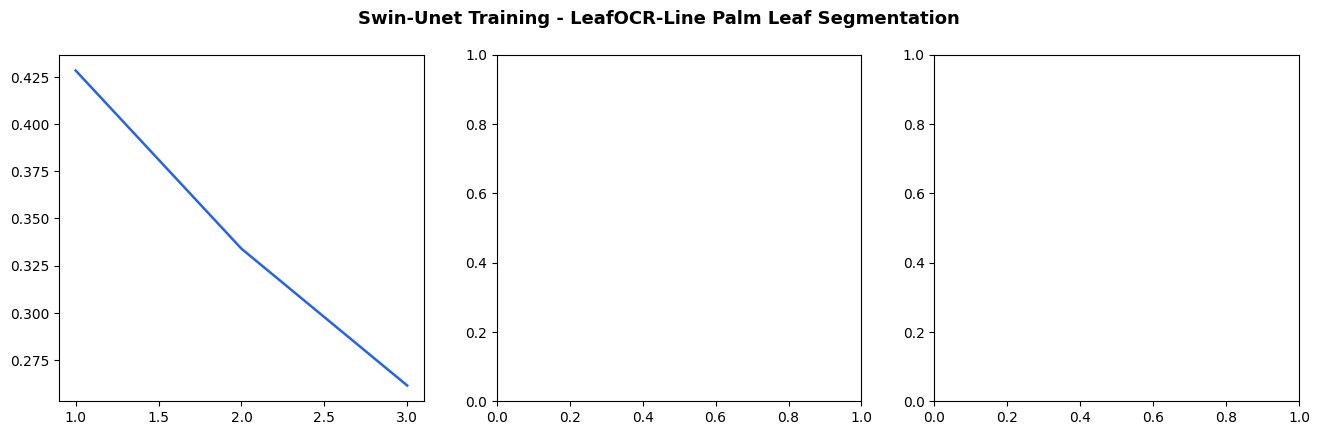

In [11]:
# ─────────────────────────────────────────────────────────────
# Cell 8: Plot loss, DSC, HD95 curves
# ─────────────────────────────────────────────────────────────
import json, matplotlib.pyplot as plt
import numpy as np

with open(CFG.CKPT_DIR / 'history.json') as f:
    h = json.load(f)

train_ep = list(range(1, len(h['train_loss'])+1))
val_ep   = list(range(CFG.EVAL_EVERY, CFG.EPOCHS+1, CFG.EVAL_EVERY))
if CFG.EPOCHS not in val_ep: val_ep.append(CFG.EPOCHS)
val_ep = val_ep[:len(h['val_dsc'])]

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
fig.suptitle('Swin-Unet Training - LeafOCR-Line Palm Leaf Segmentation',
             fontsize=13, fontweight='bold')

axes[0].plot(train_ep, h['train_loss'], '#2563EB', lw=1.8, label='Train')
axes[0].plot(val_ep,   h['val_loss'],   '#DC2626', lw=1.8, ls='--',
             marker='o', ms=4, label='Val')
axes[0].set(title='Dice+CE Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(val_ep, h['val_dsc'], '#059669', lw=2, marker='o', ms=4)
axes[1].axhline(max(h['val_dsc']), color='#059669', ls=':', lw=1, alpha=0.6)
axes[1].set(title=f'DSC  (best={max(h["val_dsc"]):.4f})', xlabel='Epoch',
            ylabel='DSC', ylim=(0,1))
axes[1].grid(alpha=0.3)

hd_finite = [v for v in h['val_hd'] if v < 1e6]
hd_ep     = [val_ep[i] for i,v in enumerate(h['val_hd']) if v < 1e6]
axes[2].plot(hd_ep, hd_finite, '#7C3AED', lw=2, marker='s', ms=4)
axes[2].set(title='HD95 (pixels)', xlabel='Epoch', ylabel='HD95')
axes[2].grid(alpha=0.3)

plt.tight_layout()
curve_path = CFG.CKPT_DIR / 'training_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {curve_path}')

## Cell 9 - Test-Set Evaluation (DSC + HD95)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Cell 9: Load best checkpoint → full test-set evaluation
#         Reports overall + per-deterioration-level metrics
# ─────────────────────────────────────────────────────────────
import json
from tqdm import tqdm
from torch.cuda.amp import autocast

ckpt = torch.load(CFG.CKPT_DIR / 'best_model.pth', map_location=CFG.DEVICE)
model.load_state_dict(ckpt['state_dict'])
print(f'Loaded: epoch {ckpt["epoch"]}  best_val_DSC={ckpt["best_dsc"]:.4f}\n')

model.eval()
overall = MetricAccumulator()
levels  = {'low': MetricAccumulator(),
           'medium': MetricAccumulator(),
           'high': MetricAccumulator()}

def guess_level(path):
    s = Path(path).stem.lower()
    if any(k in s for k in ['low','lev1']): return 'low'
    if any(k in s for k in ['high','lev3']): return 'high'
    return 'medium'

test_loss = 0.0
with torch.no_grad():
    for batch in tqdm(test_loader, desc='[test]', ncols=80):
        imgs  = batch['image'].to(CFG.DEVICE, non_blocking=True)
        masks = batch['mask'].to(CFG.DEVICE,  non_blocking=True)
        with autocast(enabled=CFG.AMP):
            logits = model(imgs)
            test_loss += criterion(logits, masks).item()
        preds = logits.argmax(1).cpu().numpy()
        gts   = masks.cpu().numpy()
        for p, g, path in zip(preds, gts, batch['img_path']):
            overall.update(p, g)
            levels[guess_level(path)].update(p, g)

res = overall.result()
res['loss'] = test_loss / len(test_loader)

print('═'*52)
print('  TEST RESULTS')
print('═'*52)
print(f'  DSC  : {res["DSC"]:.4f}')
print(f'  HD95 : {res["HD95"]:.2f} px')
print(f'  Loss : {res["loss"]:.4f}')
print()
print('  Per deterioration level:')
for lvl, acc in levels.items():
    r = acc.result()
    print(f'    {lvl:<8} | DSC={r["DSC"]:.4f}  HD95={r["HD95"]:.2f}px')

out = {'overall': res,
       'per_level': {k: v.result() for k,v in levels.items()},
       'epoch': ckpt['epoch']}
with open(CFG.CKPT_DIR / 'test_results.json','w') as f:
    json.dump(out, f, indent=2)
print(f'\nSaved: {CFG.CKPT_DIR}/test_results.json')

Loaded: epoch 3  best_val_DSC=0.8279



[test]:   0%|                                           | 0/129 [00:00<?, ?it/s]/tmp/ipykernel_3611/3539968488.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):
[test]: 100%|█████████████████████████████████| 129/129 [02:46<00:00,  1.29s/it]

════════════════════════════════════════════════════
  TEST RESULTS
════════════════════════════════════════════════════
  DSC  : 0.8266
  HD95 : 8.58 px
  Loss : 0.2987

  Per deterioration level:
    low      | DSC=nan  HD95=infpx
    medium   | DSC=0.8266  HD95=8.58px
    high     | DSC=nan  HD95=infpx

Saved: /content/drive/MyDrive/DenoisingSegmentation/Outputs/checkpoints/test_results.json



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Cell 10 - Side-by-Side: Input vs GT vs Prediction (Variable-Size)

/tmp/ipykernel_3611/364034766.py:178: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):


── Image ↔ Mask Pairing ─────────────────────────────────
  ✅  846_12.jpg                                    → 846_12.png
  ✅  846_15.jpg                                    → 846_15.png
  ✅  846_22.jpg                                    → 846_22.png
  ✅  846_3.jpg                                     → 846_3.png
  ✅  846_32.jpg                                    → 846_32.png
  ✅  846_47.jpg                                    → 846_47.png

846_12  1677×295
846_15  1697×289
846_22  1691×291
846_3  1876×363
846_32  1603×285
846_47  1585×264


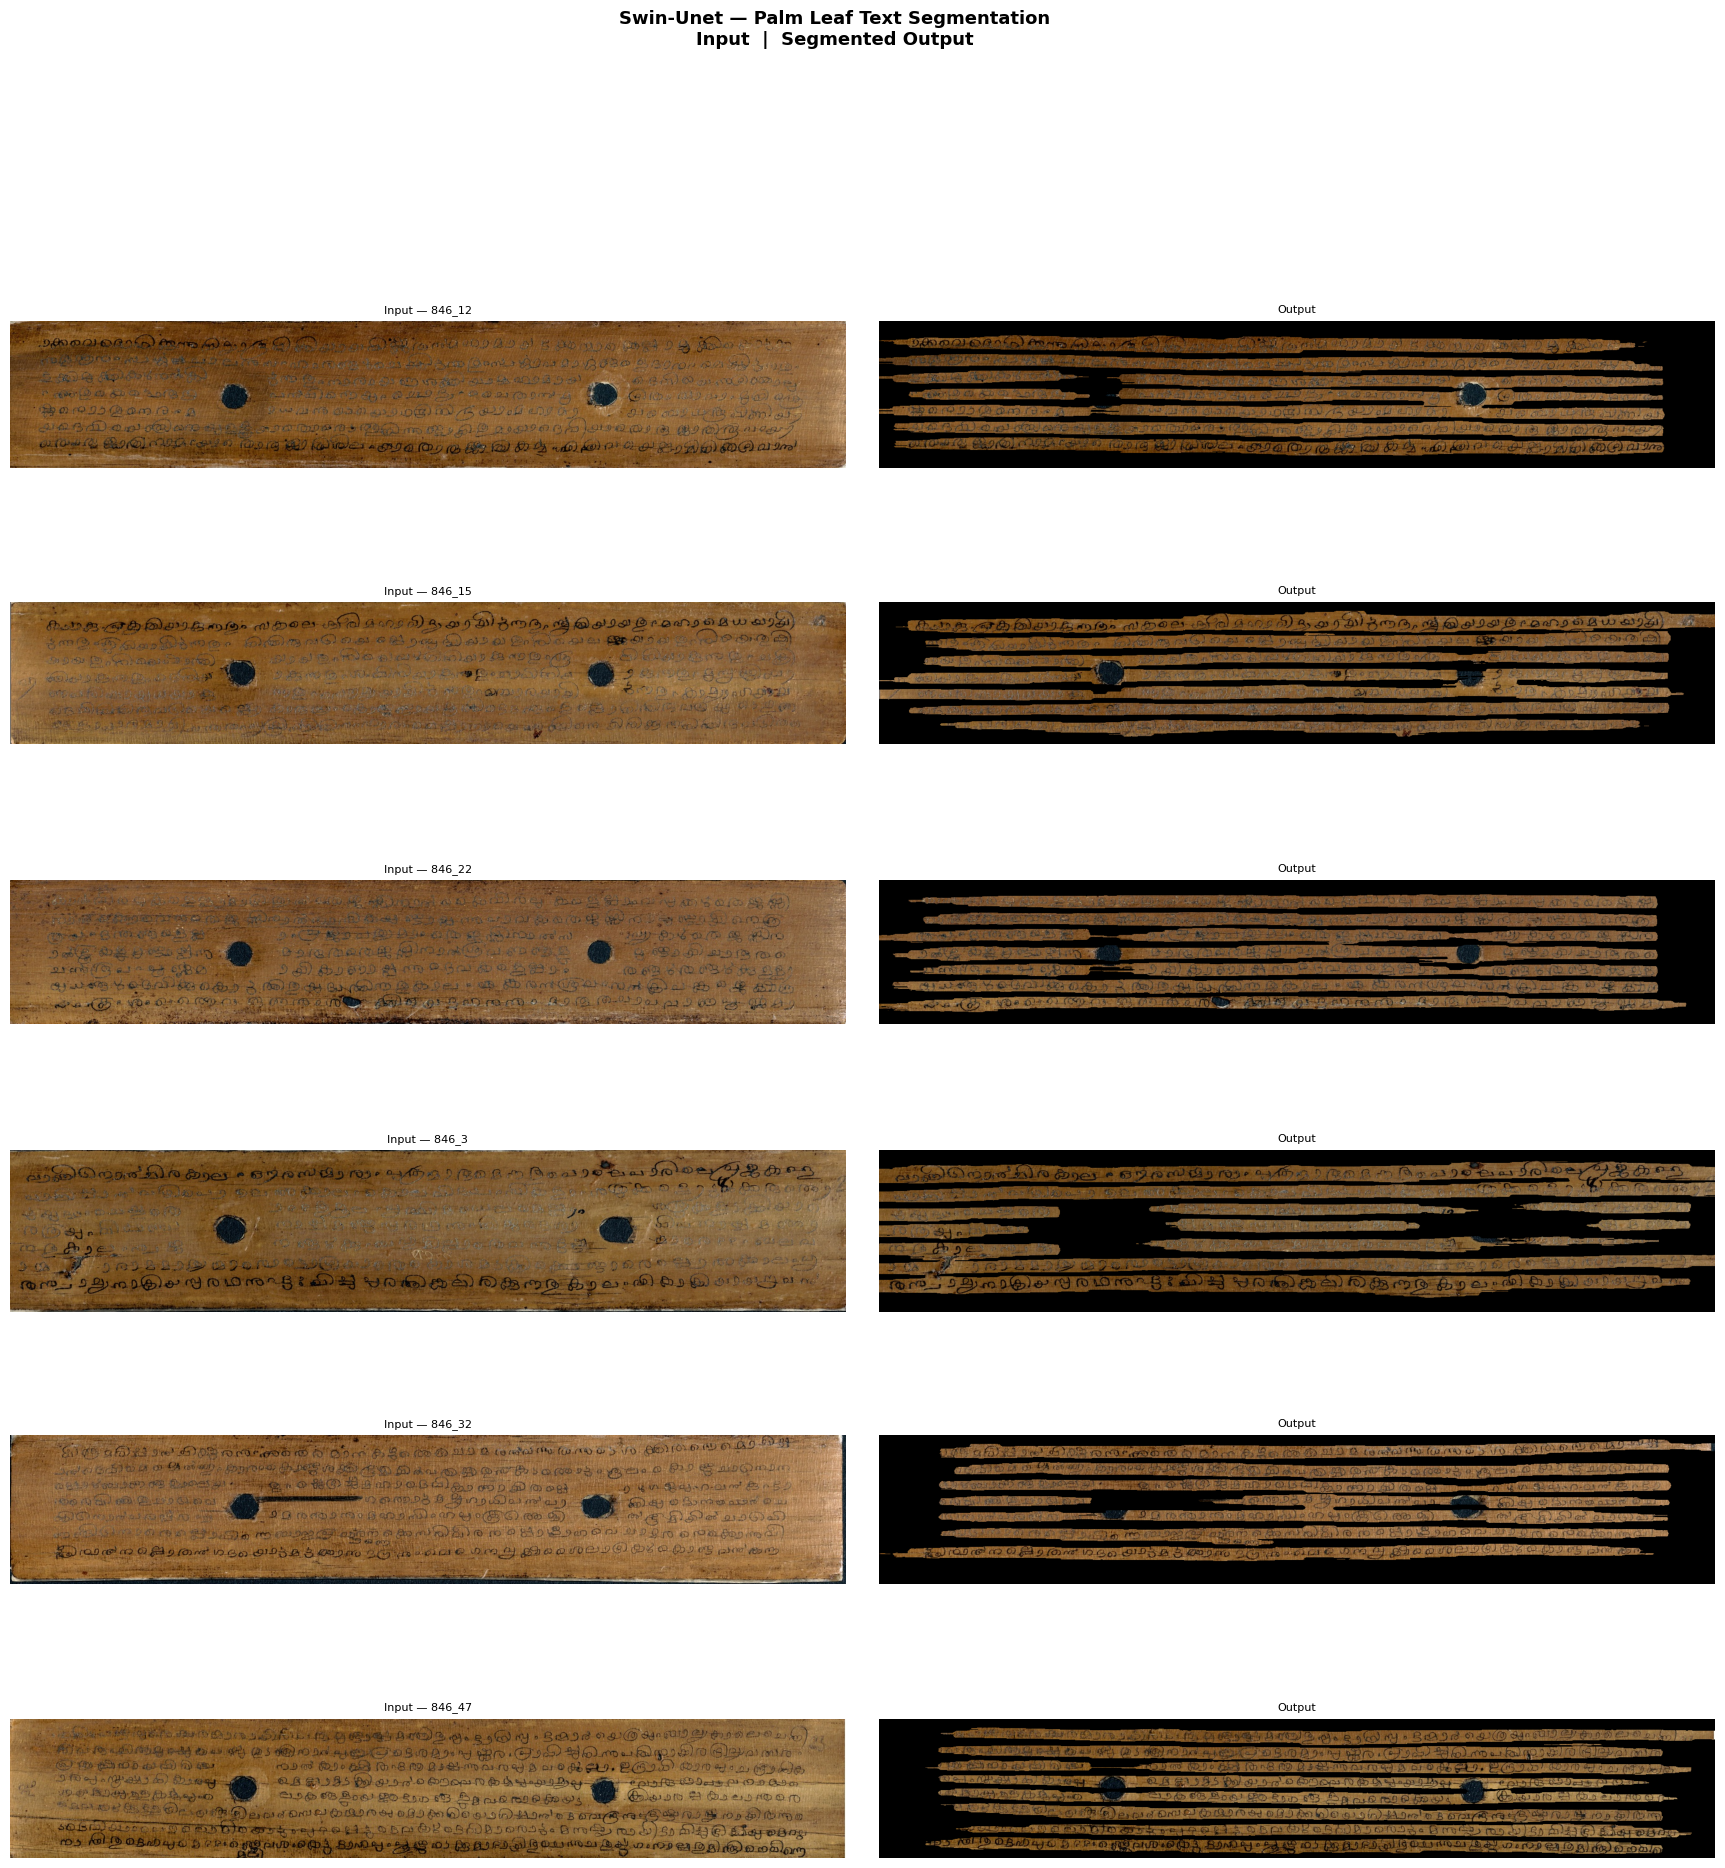


✅ Saved → /content/drive/MyDrive/DenoisingSegmentation/Outputs/predictions/qualitative_input_vs_output.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# Cell 10: Qualitative results at FULL original resolution
#
# Images are inferred at their true size (variable).
# The predicted mask is overlaid at full resolution - no
# quality is lost from the original parchment image.
# ─────────────────────────────────────────────────────────────

import cv2, numpy as np, torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from torch.cuda.amp import autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2

_MEAN = np.array([0.485, 0.456, 0.406])
_STD  = np.array([0.229, 0.224, 0.225])

_fullres_tf = A.Compose([
    A.Normalize(mean=tuple(_MEAN), std=tuple(_STD)),
    ToTensorV2(),
])


@torch.no_grad()
def infer_fullres(model, image_path, threshold=0.5):
    model.eval()
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    tensor = _fullres_tf(image=img_rgb)['image']
    inp    = tensor.unsqueeze(0).to(CFG.DEVICE)

    with autocast(enabled=CFG.AMP):
        logits = model(inp)

    probs = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()
    pred  = (probs >= threshold).astype(np.uint8)
    return img_rgb, pred


def apply_mask(img_rgb, pred_mask):
    """Keep original pixels where text is predicted; black elsewhere."""
    out = np.zeros_like(img_rgb)
    out[pred_mask == 1] = img_rgb[pred_mask == 1]
    return out


# Image ↔ Mask lookup
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

mask_lut = {
    p.stem: p
    for p in CFG.MASK_TEST.iterdir()
    if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}
}

test_imgs = sorted([
    p for p in CFG.IMAGE_TEST.iterdir()
    if p.suffix in IMG_EXTS
])[:6]

# Debug: verify pairing
print("Image ↔ Mask Pairing ")
for p in test_imgs:
    m = mask_lut.get(p.stem)
    print(f"  {'✅' if m else '❌'}  {p.name:45s} → {m.name if m else 'NO MASK FOUND'}")
print()

# ── Plot: 2 columns - Input | Output
N   = len(test_imgs)
fig = plt.figure(figsize=(22, 3.5 * N))
fig.suptitle(
    "Swin-Unet - Palm Leaf Text Segmentation\n"
    "Input  |  Segmented Output",
    fontsize=13, fontweight='bold', y=1.01
)

gs = gridspec.GridSpec(N, 2, hspace=0.25, wspace=0.04)

for row, img_path in enumerate(test_imgs):
    img_rgb, pred_m = infer_fullres(model, img_path)
    masked_out      = apply_mask(img_rgb, pred_m)

    # Save output
    cv2.imwrite(
        str(CFG.PRED_DIR / f'{img_path.stem}_output.png'),
        cv2.cvtColor(masked_out, cv2.COLOR_RGB2BGR)
    )

    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(img_rgb)
    ax0.set_title(f"Input - {img_path.stem}", fontsize=8)
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[row, 1])
    ax1.imshow(masked_out)
    ax1.set_title("Output", fontsize=8)
    ax1.axis('off')

    print(f"{img_path.stem}  {img_rgb.shape[1]}×{img_rgb.shape[0]}")

save_path = CFG.PRED_DIR / 'qualitative_input_vs_output.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'\n✅ Saved → {save_path}')
